# Feature Engineering

In [21]:
# Create Date-Time Features
germany_entso_df["hour"] = germany_entso_df.index.hour
germany_entso_df["dayofweek"] = germany_entso_df.index.dayofweek
germany_entso_df['is_weekend'] = germany_entso_df["dayofweek"].isin([5,6]).astype(int)
germany_entso_df["quarter"] = germany_entso_df.index.quarter
germany_entso_df["month"] = germany_entso_df.index.month
germany_entso_df["year"] = germany_entso_df.index.year
germany_entso_df["dayofyear"] = germany_entso_df.index.dayofyear
germany_entso_df.head()

,electricity_load_MW,hour,dayofweek,is_weekend,quarter,month,year,dayofyear
Timestamp,,,,,,,,
2015-01-01 00:00:00+01:00,45000.50,0,3,0,1,1,2015,1
2015-01-01 01:00:00+01:00,43833.25,1,3,0,1,1,2015,1
2015-01-01 02:00:00+01:00,42322.25,2,3,0,1,1,2015,1
2015-01-01 03:00:00+01:00,40966.00,3,3,0,1,1,2015,1
2015-01-01 04:00:00+01:00,40283.50,4,3,0,1,1,2015,1


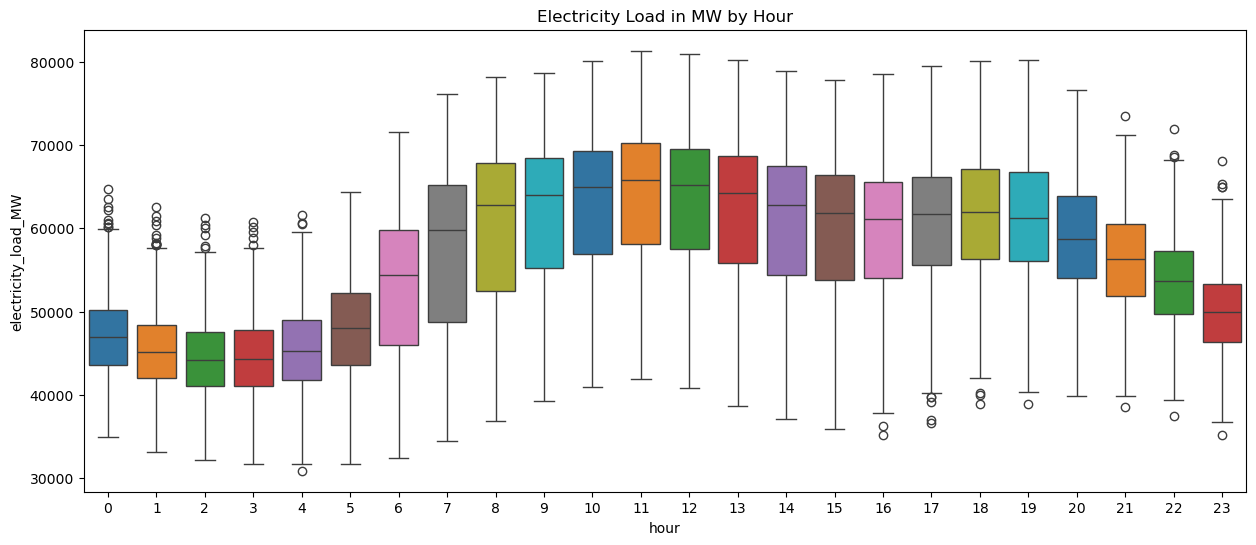

In [22]:
# Boxplot to visualize distribution of electricity Load across different Hours
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=germany_entso_df, x="hour", y="electricity_load_MW", hue="hour", palette="tab10", legend=False)
ax.set_title("Electricity Load in MW by Hour");

Text(0.5, 1.0, 'Electricity Load in MW by Month')

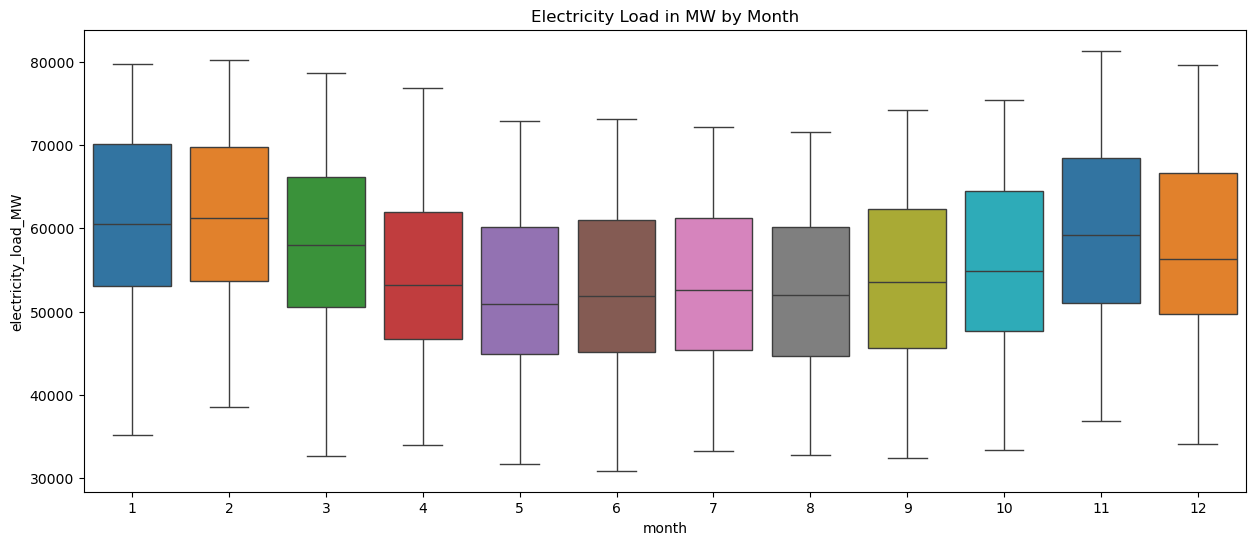

In [23]:
# Boxplot to visualize distribution of electricity Load across different months
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=germany_entso_df, x="month", y="electricity_load_MW",  hue="month", palette="tab10", legend=False)
ax.set_title("Electricity Load in MW by Month")
# Looking at the graph, we can see that MW uses by the month terms to peak two times in the Winter season than the fall and spring seasons has a lower than another peak in the middle of summer when everyone running their AC units.

In [24]:
# Lag Features
germany_entso_df["electricity_load_lag_1"] = germany_entso_df["electricity_load_MW"].shift(1)
germany_entso_df["electricity_load_lag_24"] = germany_entso_df["electricity_load_MW"].shift(24)
germany_entso_df["electricity_load_lag_48"] = germany_entso_df["electricity_load_MW"].shift(48)
germany_entso_df["electricity_load_lag_168"] = germany_entso_df["electricity_load_MW"].shift(168) 
germany_entso_df["electricity_load_lag_720"] = germany_entso_df["electricity_load_MW"].shift(720)

# Rolling Statistics
germany_entso_df["electricity_load_rolling_24_mean"] = germany_entso_df["electricity_load_MW"].shift(1).rolling(24).mean()
germany_entso_df["electricity_load_rolling_std_24"] = germany_entso_df["electricity_load_MW"].shift(1).rolling(24).std()
germany_entso_df["electricity_load_rolling_168_mean"] = germany_entso_df["electricity_load_MW"].shift(1).rolling(168).mean()

germany_entso_df.head()

,electricity_load_MW,hour,dayofweek,is_weekend,quarter,month,year,dayofyear,electricity_load_lag_1,electricity_load_lag_24,electricity_load_lag_48,electricity_load_lag_168,electricity_load_lag_720,electricity_load_rolling_24_mean,electricity_load_rolling_std_24,electricity_load_rolling_168_mean
Timestamp,,,,,,,,,,,,,,,,
2015-01-01 00:00:00+01:00,45000.50,0,3,0,1,1,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00+01:00,43833.25,1,3,0,1,1,2015,1,45000.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 02:00:00+01:00,42322.25,2,3,0,1,1,2015,1,43833.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 03:00:00+01:00,40966.00,3,3,0,1,1,2015,1,42322.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 04:00:00+01:00,40283.50,4,3,0,1,1,2015,1,40966.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Drop rows with NaN values
germany_entso_df = germany_entso_df.dropna()  
germany_entso_df = germany_entso_df.sort_index()
germany_entso_df

,electricity_load_MW,hour,dayofweek,is_weekend,quarter,month,year,dayofyear,electricity_load_lag_1,electricity_load_lag_24,electricity_load_lag_48,electricity_load_lag_168,electricity_load_lag_720,electricity_load_rolling_24_mean,electricity_load_rolling_std_24,electricity_load_rolling_168_mean
Timestamp,,,,,,,,,,,,,,,,
2015-01-31 00:00:00+01:00,54393.00,0,5,1,1,1,2015,31,58376.50,54632.00,54432.25,55461.75,45000.50,65557.572917,8317.166539,63586.467262
2015-01-31 01:00:00+01:00,51980.25,1,5,1,1,1,2015,31,54393.00,52414.50,52259.75,53024.75,43833.25,65547.614583,8330.948397,63580.105655
2015-01-31 02:00:00+01:00,50705.50,2,5,1,1,1,2015,31,51980.25,51878.25,50696.00,53935.50,42322.25,65529.520833,8361.128885,63573.888393
2015-01-31 03:00:00+01:00,50054.25,3,5,1,1,1,2015,31,50705.50,52119.75,51249.50,54274.00,40966.00,65480.656250,8447.361424,63554.662202
2015-01-31 04:00:00+01:00,49981.00,4,5,1,1,1,2015,31,50054.25,53252.00,52557.50,54233.50,40283.50,65394.593750,8598.570350,63529.544643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-09 16:00:00+02:00,39745.00,16,0,0,2,6,2025,160,38835.00,40581.75,45767.50,56940.50,41052.00,39644.552083,3207.425773,48815.668155
2025-06-09 17:00:00+02:00,41381.50,17,0,0,2,6,2025,160,39745.00,42501.25,46002.75,57426.25,42602.00,39609.687500,3201.337485,48713.313988
2025-06-09 18:00:00+02:00,43501.00,18,0,0,2,6,2025,160,41381.50,44028.75,46597.00,57160.25,45111.50,39563.031250,3165.320654,48617.809524


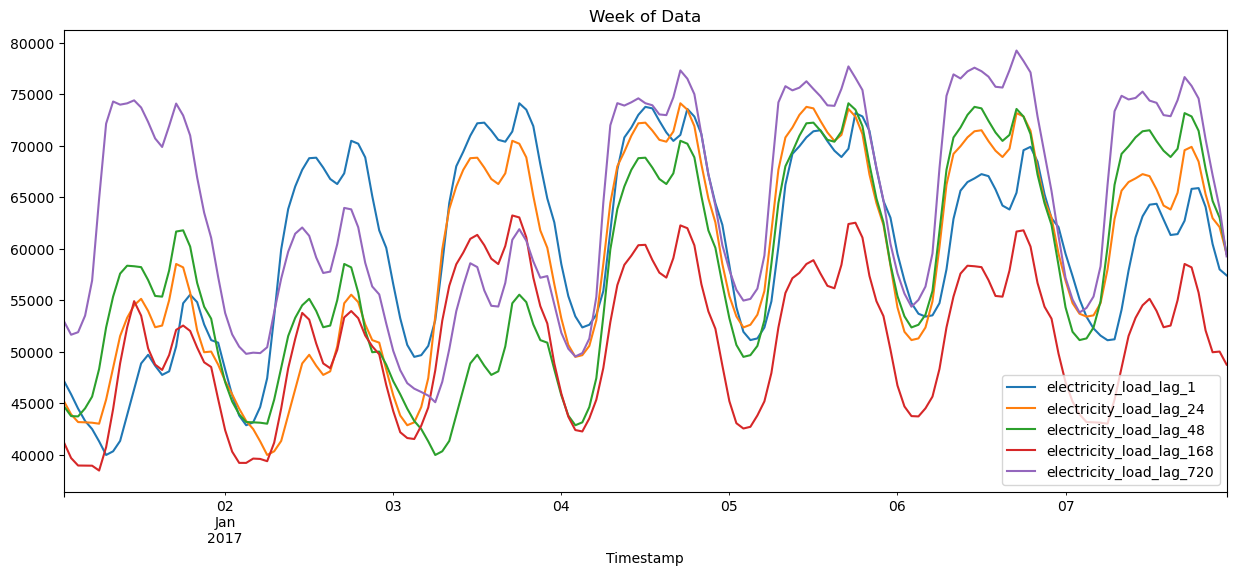

In [26]:
# Visualize all lag features (1 Week) over Time 
germany_entso_df[["electricity_load_lag_1", 
                  "electricity_load_lag_24", 
                  "electricity_load_lag_48", 
                  "electricity_load_lag_168", 
                  "electricity_load_lag_720"
                 ]].loc[(germany_entso_df.index > "2017-01-01") & (germany_entso_df.index < "2017-01-08")].plot(figsize=(15, 6), title="Week of Data")
plt.legend()
plt.show();

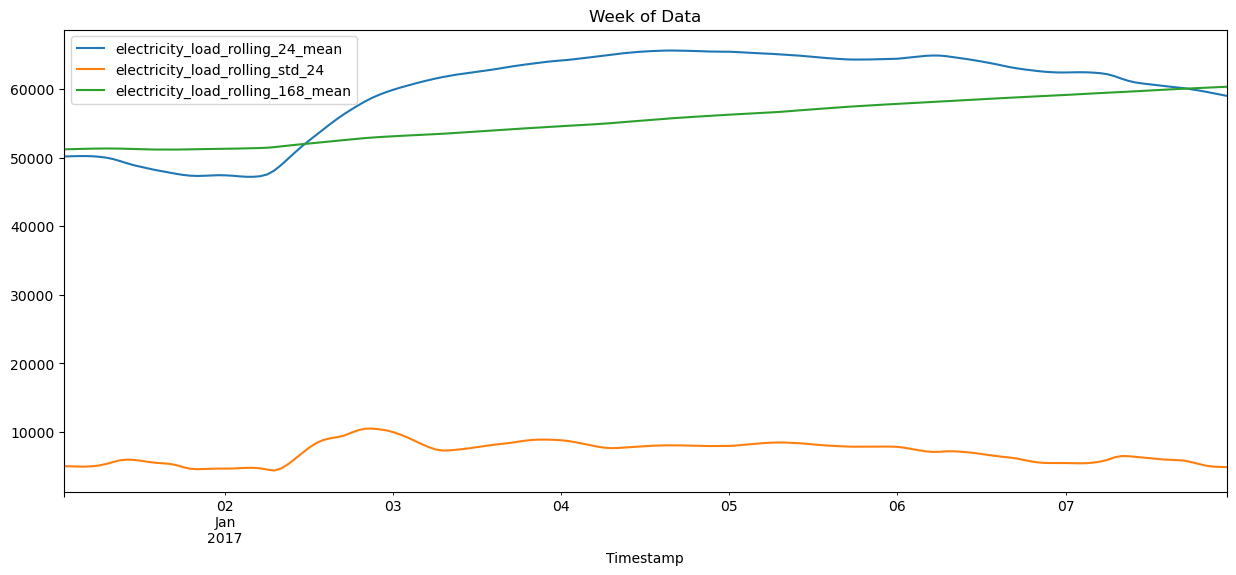

In [27]:
# Visualize all rolling statistics (1 Week) over Time 
germany_entso_df[["electricity_load_rolling_24_mean", 
                  "electricity_load_rolling_std_24", 
                  "electricity_load_rolling_168_mean"
                 ]].loc[(germany_entso_df.index > "2017-01-01") & (germany_entso_df.index < "2017-01-08")].plot(figsize=(15, 6), title="Week of Data")
plt.legend()
plt.show();

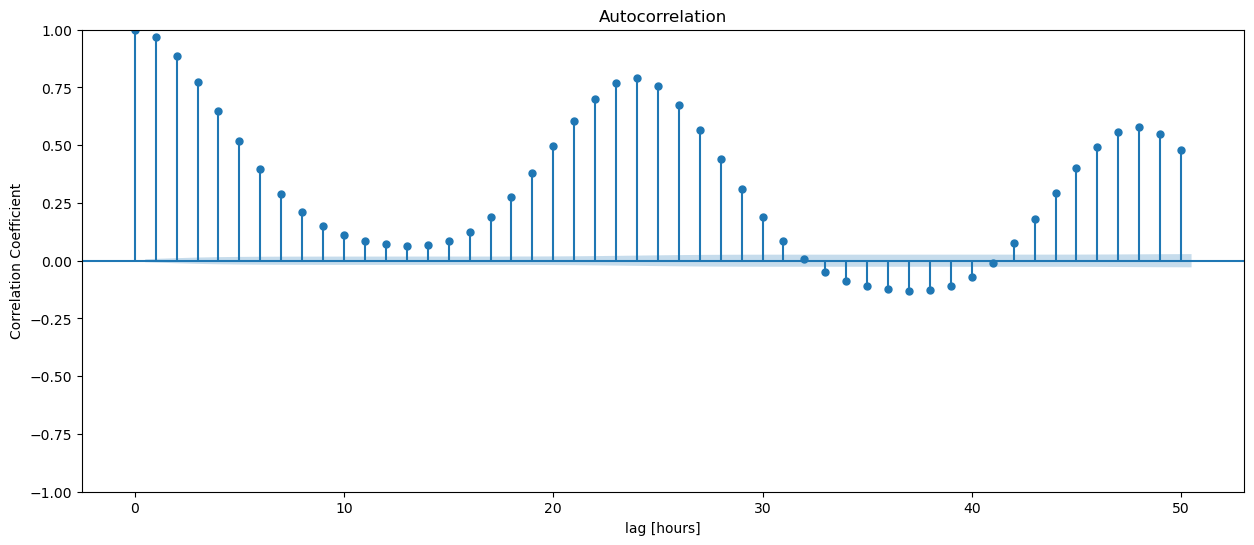

In [28]:
# Create an Autocorrelation Fuction (ACF) plot
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(germany_entso_df["electricity_load_MW"], ax=ax)
plt.xlabel("lag [hours]")
plt.ylabel("Correlation Coefficient");

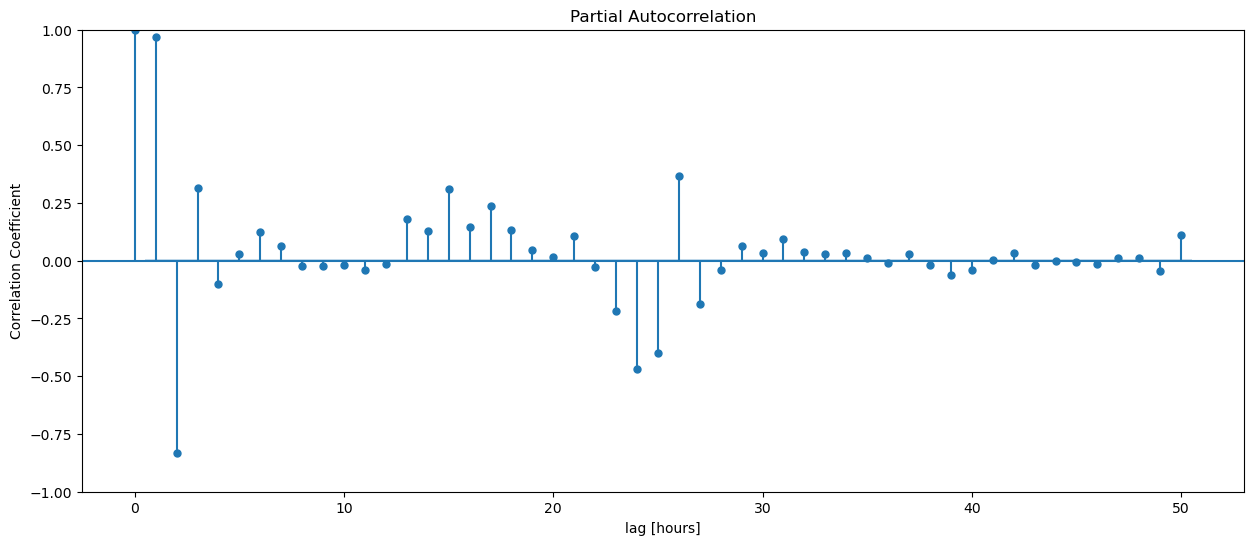

In [29]:
# Create an Partial Autocorrelation Function (PACF) plot
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(germany_entso_df["electricity_load_MW"], ax=ax)
plt.xlabel("lag [hours]")
plt.ylabel("Correlation Coefficient");

In [30]:
# Check full correlation matrix numbers
germany_entso_df.corr()

,electricity_load_MW,hour,dayofweek,is_weekend,quarter,month,year,dayofyear,electricity_load_lag_1,electricity_load_lag_24,electricity_load_lag_48,electricity_load_lag_168,electricity_load_lag_720,electricity_load_rolling_24_mean,electricity_load_rolling_std_24,electricity_load_rolling_168_mean
electricity_load_MW,1.000000,0.367029,-0.368610,-0.458353,-0.084357,-0.084506,-0.158002,-0.084830,0.968846,0.789088,0.578912,0.916302,0.489651,0.603670,0.424919,0.428835
hour,0.367029,1.000000,0.000098,0.000056,-0.000405,-0.000317,-0.000061,-0.000312,0.453390,0.367009,0.366925,0.366317,0.364633,-0.000224,0.032772,-0.000163
dayofweek,-0.368610,0.000098,1.000000,0.790724,0.001753,0.002121,-0.000098,0.001956,-0.361692,0.081644,0.356140,-0.369058,0.355724,-0.201489,-0.268558,0.000032
is_weekend,-0.458353,0.000056,0.790724,1.000000,0.001546,0.000943,-0.000332,0.000880,-0.453844,-0.102957,0.175933,-0.458471,0.175386,-0.418983,-0.370853,0.000378
quarter,-0.084357,-0.000405,0.001753,0.001546,1.000000,0.971377,-0.087913,0.968275,-0.084275,-0.080259,-0.078043,-0.059599,-0.146514,-0.123320,0.116514,-0.163432
month,-0.084506,-0.000317,0.002121,0.000943,0.971377,1.000000,-0.092064,0.996470,-0.084375,-0.078624,-0.075109,-0.046881,-0.131993,-0.122116,0.114728,-0.151593
year,-0.158002,-0.000061,-0.000098,-0.000332,-0.087913,-0.092064,1.000000,-0.091848,-0.158023,-0.158369,-0.158564,-0.161980,-0.149823,-0.237218,-0.276653,-0.353629
dayofyear,-0.084830,-0.000312,0.001956,0.000880,0.968275,0.996470,-0.091848,1.000000,-0.084669,-0.078066,-0.074067,-0.043212,-0.134548,-0.121828,0.114474,-0.147992
electricity_load_lag_1,0.968846,0.453390,-0.361692,-0.453844,-0.084275,-0.084375,-0.158023,-0.084669,1.000000,0.768266,0.557750,0.886602,0.468730,0.616834,0.443416,0.429922
electricity_load_lag_24,0.789088,0.367009,0.081644,-0.102957,-0.080259,-0.078624,-0.158369,-0.078066,0.768266,1.000000,0.789041,0.748395,0.683091,0.616596,0.395443,0.446789


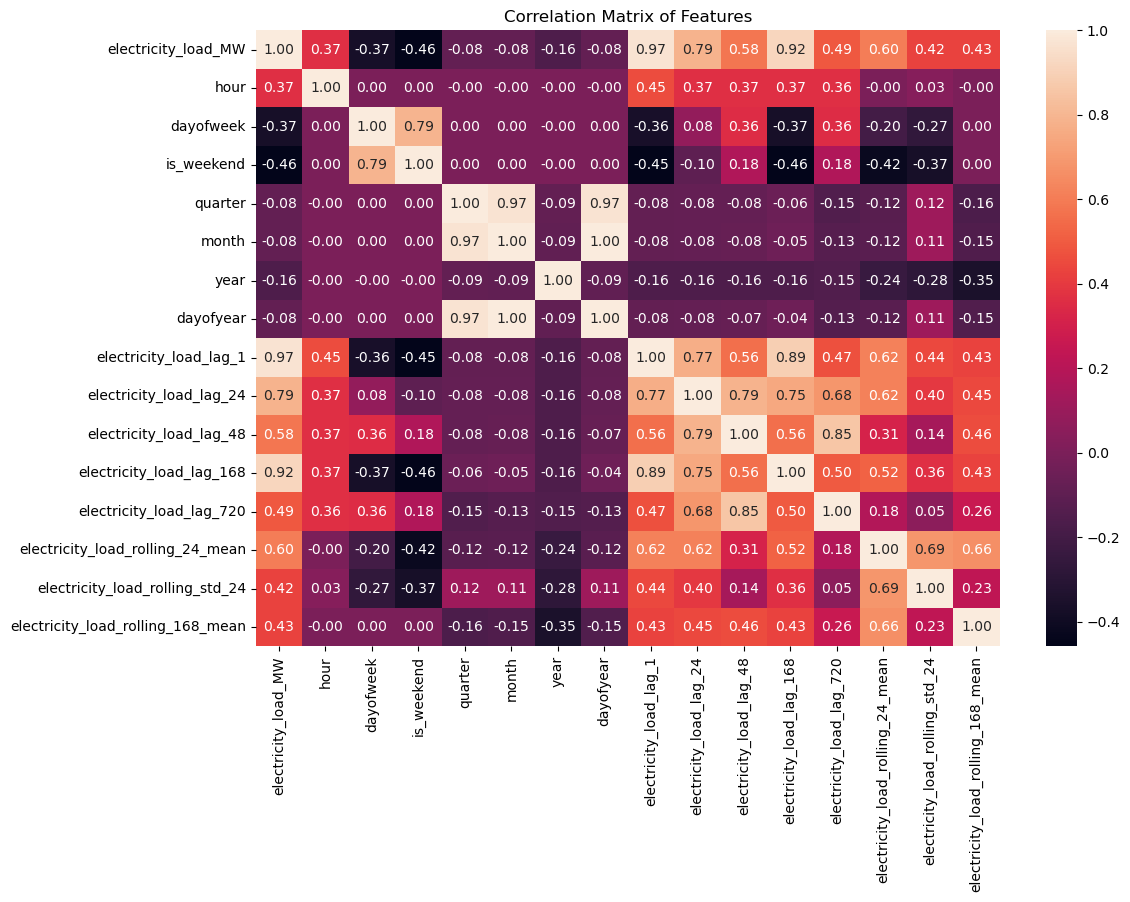

In [31]:
# Correlation Matrix, Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(germany_entso_df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()